# How are in-demand skills trending for Data Analysts?

## Methodology


- Aggregate skills counts montly 
- Re-analysis based on percent of total jobs
- Plot the montly skills demand

In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df=dataset["train"].to_pandas()

# Data Cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

C:\Users\IDEAPADGAMING\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_In=df[(df['job_country']=='India') & (df['job_title']=='Data Analyst')]

In [3]:
df_In['job_posted_month_no']=pd.to_datetime(df_In['job_posted_date']).dt.month

In [4]:
df_In_explode=df_In.explode('job_skills')

In [11]:
df_In_pivot=df_In_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_In_pivot.loc['Total'] = df_In_pivot.sum()

df_In_pivot=df_In_pivot[df_In_pivot.loc['Total'].sort_values(ascending=False).index]

In [12]:
df_In_pivot.drop('Total', inplace=True)

In [14]:
df_In_total=df_In.groupby('job_posted_month_no').size()

In [25]:
df_In_perc=df_In_pivot.div(df_In_total, axis=0) * 100

In [ ]:
df_In_perc=df_In_perc.reset_index()
df_In_perc['job_posted_month']=df_In_perc['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_In_perc=df_In_perc.set_index('job_posted_month')
df_In_perc.drop(columns='job_posted_month_no', inplace=True)

job_skills,sql,python,excel,tableau,power bi,sas,r,aws,azure,javascript,...,react.js,sqlite,suse,swift,tidyr,unify,vb.net,watson,webex,wire
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,52.083333,38.194444,35.416667,28.472222,18.055556,25.000000,15.972222,4.166667,3.472222,7.638889,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.694444,0.000000
Feb,54.237288,33.898305,38.983051,27.118644,20.338983,11.864407,19.491525,5.084746,5.932203,6.779661,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.847458,0.000000,0.000000
Mar,58.762887,25.773196,32.989691,30.927835,19.587629,10.309278,9.278351,7.216495,6.185567,3.092784,...,0.000000,0.000000,1.030928,1.030928,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Apr,56.565657,35.353535,35.353535,27.272727,23.232323,24.242424,16.161616,4.040404,8.080808,7.070707,...,1.010101,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
May,68.750000,39.062500,57.812500,37.500000,28.125000,15.625000,14.062500,6.250000,14.062500,4.687500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Jun,53.763441,45.161290,36.559140,31.182796,24.731183,30.107527,24.731183,10.752688,9.677419,5.376344,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Jul,61.956522,40.217391,40.217391,41.304348,21.739130,21.739130,25.000000,5.434783,8.695652,5.434783,...,0.000000,0.000000,0.000000,0.000000,1.086957,0.00000,0.000000,0.000000,0.000000,0.000000
Aug,62.411348,41.134752,38.297872,33.333333,30.496454,17.021277,19.858156,14.184397,7.801418,4.964539,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Sep,57.831325,39.156627,35.542169,31.927711,25.903614,15.662651,16.265060,7.228916,3.012048,8.433735,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.60241,0.000000,0.000000,0.000000,0.000000


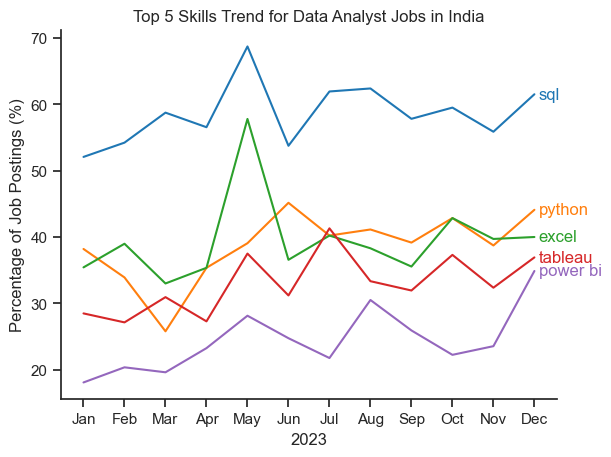

In [39]:
df_plot=df_In_perc.iloc[:,:5]

sns.lineplot(data=df_plot,dashes=False,palette='tab10')
sns.set_theme(style='ticks')

plt.title('Top 5 Skills Trend for Data Analyst Jobs in India')
plt.xlabel('2023')
plt.ylabel('Percentage of Job Postings (%)')
plt.legend().remove()
sns.despine()

for i in range(5):
    plt.text(11.1,df_plot.iloc[-1,i], df_plot.columns[i], color=sns.color_palette('tab10')[i], va='center')

# Investigate Median Salary vs Skill for Data Analysts

In [40]:
df_DA_In=df[(df['job_country']=='India') & (df['job_title']=='Data Analyst')].dropna(subset=['salary_year_avg'])

In [41]:
df_DA_In=df_DA_In.explode('job_skills')

In [ ]:
df_DA_skills=df_DA_In.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median',ascending=False)

df_DA_top_pay=df_DA_skills.head(10)

df_DA_top_pay

,count,median
job_skills,,
looker,2,111188.5
express,2,111188.5
dax,1,111175.0
jira,1,111175.0
airflow,1,111175.0
excel,5,111175.0
tableau,5,111175.0
sql,8,111175.0
r,4,111175.0


In [45]:
df_DA_skills=df_DA_In.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)

df_DA_skills=df_DA_skills.head(10)

df_DA_skills

,count,median
job_skills,,
sql,8,111175.0
python,6,111175.0
excel,5,111175.0
tableau,5,111175.0
powerpoint,4,111175.0
r,4,111175.0
spark,3,111175.0
power bi,3,111175.0
go,2,111175.0


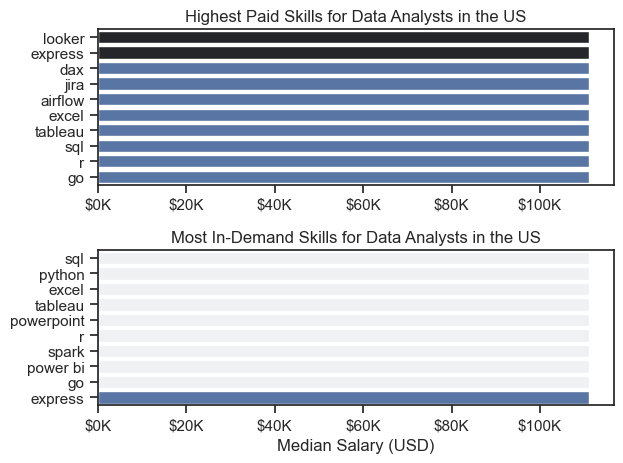

In [48]:
fig, ax = plt.subplots(2, 1)  

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, hue='median', ax=ax[0], palette='dark:b_r')
ax[0].legend().remove()
# original code:
# df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False) 
ax[0].set_title('Highest Paid Skills for Data Analysts in the US')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analysts')
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, hue='median', ax=ax[1], palette='light:b')
ax[1].legend().remove()
# original code:
# df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Most In-Demand Skills for Data Analysts in the US')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.set_theme(style='ticks')
plt.tight_layout()
plt.show()